In [1]:
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_omni
importlib.reload(run_omni)
from run_omni import omniprediction_multiq_online, OmniResult

In [2]:
d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp_weekly.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
Y = d['Y']

print(f_list)
print(alpha_list)
print(dates_list)
print(Y)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
Index(['2021-02-23', '2021-03-02', '2021-03-09', '2021-03-16', '2021-03-23',
       '2021-03-30', '2021-04-06', '2021-04-13', '2021-04-20', '2021-04-27',
       ...
       '2023-03-28', '2023-04-04', '2023-04-11', '2023-04-18', '2023-04-25',
       '2023-05-02', '2023-05-09', '2023-05-16', '2023-05-23', '2023-05-30'],
      dtype='str', length=119)
2021-02-23    39206.0
2021-03-02    34961.0
2021-03-09    33410.0
2021-03-16    33334.0
2021-03-23    35409.0
               ...   
2023-05-02     9721.0
2023-05-09     8832.0
2023-05-16     8328.0
2023-05-23     7579.0
2023-05-30     7310.0
Name: actual, Length: 119, dtype: float64


In [188]:
max_val = 0
for forecaster in f_list:
    max_val = max(max_val, forecasts_dict[4][f'{forecaster}'][0.99].max()) 
max_val

np.float64(1301622.219871009)

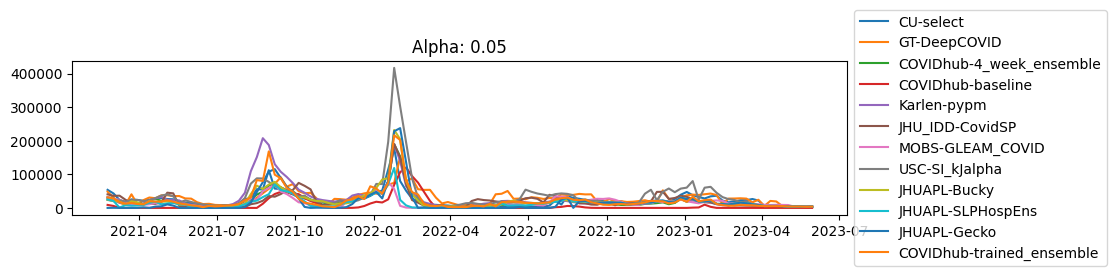

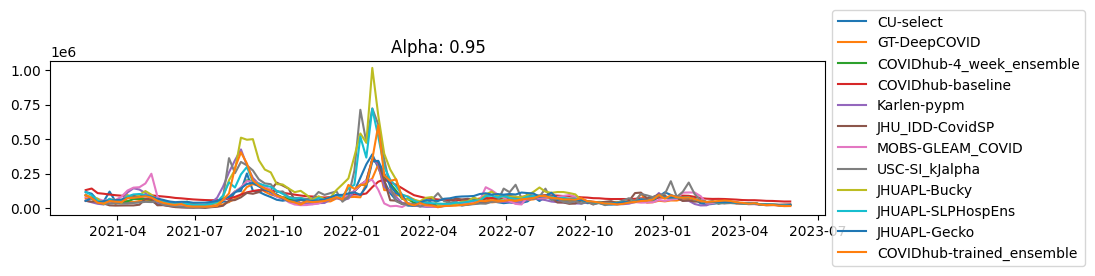

In [ ]:
for alpha in [0.05, 0.95]:
    plt.figure(figsize=(10, 2))
    for forecaster in f_list:
        plt.plot(pd.to_datetime(d['dates_list']), 
        forecasts_dict[4][f'{forecaster}'][alpha], label=forecaster) 
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f'Alpha: {alpha}')
    plt.show()


In [4]:
def decimal_to_str(eta):
    return int(eta) if eta >= 1 else str(eta).replace('.', '')

def exp_name_string(w, eta, eta_f, seed):
    return f"wk{w}_eta{decimal_to_str(eta)}_etaf{decimal_to_str(eta_f)}_seed{seed}"

save_folder = 'hosp0315_weekly'
SAVE_DIR = f'../results/{save_folder}'

# alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])
alpha_list_here = alpha_list

In [168]:
eta_multiplier = 1
eta_f_multiplier = 8

for w in range(1,5):
    for eta_f_multiplier in [1, 2, 4, 8, 16]:
        print(f"Running wk{w} with eta_f_multiplier={eta_f_multiplier}...")
        for seed in range(1,11):
            results = omniprediction_multiq_online(Y=d['Y'][d['dates_list']], 
                                                    forecasts_dict=forecasts_dict[w], 
                                                    unit=500, 
                                                    alpha_list=alpha_list_here, 
                                                    eta_multiplier=eta_multiplier, 
                                                    eta_f_multiplier=eta_f_multiplier, 
                                                    seed=seed, 
                                                    verbose=False
                                                    )
            exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
            omni_result = OmniResult(results)
            pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
            pickle.dump(omni_result, open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'wb'))

Running wk1 with eta_f_multiplier=1...


119it [00:01, 74.56it/s]
119it [00:01, 73.26it/s]
119it [00:01, 77.98it/s]
119it [00:01, 69.55it/s]
119it [00:01, 71.68it/s]
119it [00:01, 71.71it/s]
119it [00:01, 79.29it/s]
119it [00:01, 68.98it/s]
119it [00:01, 65.63it/s]
119it [00:01, 77.06it/s]


Running wk1 with eta_f_multiplier=2...


119it [00:01, 75.95it/s]
119it [00:01, 76.54it/s]
119it [00:01, 79.53it/s]
119it [00:01, 79.44it/s]
119it [00:01, 81.47it/s]
119it [00:01, 80.68it/s]
119it [00:01, 77.96it/s]
119it [00:01, 72.45it/s]
119it [00:01, 78.17it/s]
119it [00:01, 77.30it/s]


Running wk1 with eta_f_multiplier=4...


...

119it [00:04, 27.35it/s]
119it [00:04, 28.91it/s]
119it [00:04, 29.14it/s]
119it [00:04, 27.39it/s]
119it [00:04, 27.14it/s]
119it [00:04, 28.73it/s]
119it [00:04, 26.22it/s]
119it [00:04, 28.81it/s]
119it [00:04, 26.85it/s]
119it [00:04, 28.48it/s]


Running wk4 with eta_f_multiplier=8...


119it [00:04, 27.34it/s]
119it [00:04, 25.89it/s]
119it [00:04, 25.76it/s]
119it [00:04, 28.92it/s]
119it [00:04, 27.82it/s]
119it [00:04, 27.17it/s]
119it [00:04, 28.08it/s]
119it [00:04, 26.24it/s]
119it [00:04, 27.73it/s]
119it [00:04, 26.70it/s]


Running wk4 with eta_f_multiplier=16...


119it [00:04, 29.38it/s]
119it [00:04, 28.01it/s]
119it [00:04, 28.51it/s]
119it [00:04, 28.98it/s]
119it [00:04, 28.06it/s]
119it [00:03, 29.75it/s]
119it [00:03, 29.89it/s]
119it [00:04, 28.94it/s]
119it [00:03, 29.90it/s]
119it [00:04, 29.43it/s]


In [169]:
alpha_list_here = d['alpha_list']

eta_f_multiplier = 4
for eta_multiplier in [0.5, 2, 4]:
    for w in range(1,5):
        print(f"Running wk{w} with eta_multiplier={eta_multiplier}...")
        for seed in range(1,11):
            results = omniprediction_multiq_online(Y=d['Y'][d['dates_list']], 
                                                    forecasts_dict=forecasts_dict[w], 
                                                    unit=500, 
                                                    alpha_list=alpha_list_here, 
                                                    eta_multiplier=eta_multiplier, 
                                                    eta_f_multiplier=eta_f_multiplier, 
                                                    seed=seed, 
                                                    verbose=False)
            omni_result = OmniResult(results)
            exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
            pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
            pickle.dump(omni_result, open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'wb'))

Running wk1 with eta_multiplier=0.5...


119it [00:01, 74.37it/s]
119it [00:01, 80.63it/s]
119it [00:01, 81.02it/s]
119it [00:01, 80.79it/s]
119it [00:01, 81.00it/s]
119it [00:01, 78.73it/s]
119it [00:01, 81.36it/s]
119it [00:01, 80.56it/s]
119it [00:01, 81.22it/s]
119it [00:01, 81.31it/s]


Running wk2 with eta_multiplier=0.5...


119it [00:02, 52.45it/s]
119it [00:02, 55.40it/s]
119it [00:02, 54.88it/s]
119it [00:02, 55.44it/s]
119it [00:02, 55.37it/s]
119it [00:02, 55.47it/s]
119it [00:02, 55.15it/s]
119it [00:02, 55.52it/s]
119it [00:02, 53.56it/s]
119it [00:02, 55.46it/s]


Running wk3 with eta_multiplier=0.5...


...

119it [00:02, 54.68it/s]
119it [00:02, 55.08it/s]
119it [00:02, 54.70it/s]
119it [00:02, 54.91it/s]
119it [00:02, 55.07it/s]
119it [00:02, 52.90it/s]
119it [00:02, 55.08it/s]
119it [00:02, 55.24it/s]
119it [00:02, 55.25it/s]
119it [00:02, 55.05it/s]


Running wk3 with eta_multiplier=4...


119it [00:03, 39.01it/s]
119it [00:02, 40.60it/s]
119it [00:02, 40.57it/s]
119it [00:02, 40.55it/s]
119it [00:02, 40.66it/s]
119it [00:02, 39.69it/s]
119it [00:02, 40.69it/s]
119it [00:02, 40.53it/s]
119it [00:02, 40.64it/s]
119it [00:02, 40.35it/s]


Running wk4 with eta_multiplier=4...


119it [00:04, 27.59it/s]
119it [00:04, 29.06it/s]
119it [00:04, 27.26it/s]
119it [00:04, 28.13it/s]
119it [00:04, 29.38it/s]
119it [00:04, 28.86it/s]
119it [00:04, 28.10it/s]
119it [00:04, 28.82it/s]
119it [00:03, 29.77it/s]
119it [00:04, 29.08it/s]


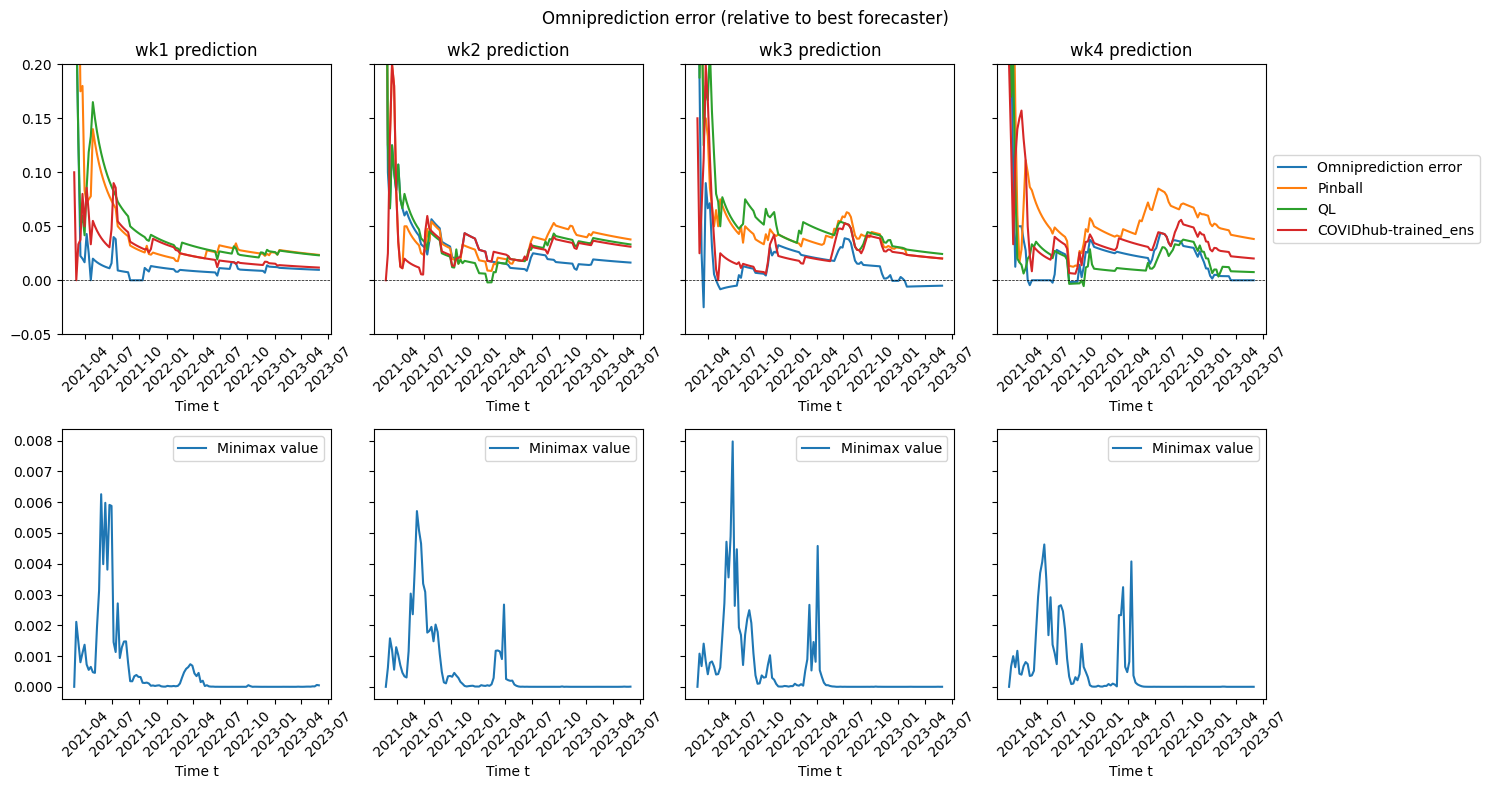

In [ ]:
eta_multiplier = 1
eta_f_multiplier = 8
seed = 1

fig, ax = plt.subplots(2, 4, figsize=(15, 8), sharey='row')

for w in range(1,5):
    exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
    omni_result = OmniResult(results)
    ax[0, w-1] = omni_result.simple_plot(ax=ax[0,w-1])
    ax[0, w-1].set_title(f'wk{w} ahead prediction data')
    ax[0, w-1].set_ylim(-0.05, 0.2)
    ax[1,w-1] = omni_result.minimax_plot(ax=ax[1,w-1])
    if w == 4:
        ax[0, w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('Omniprediction error (relative to best forecaster)')
fig.tight_layout()
plt.show()

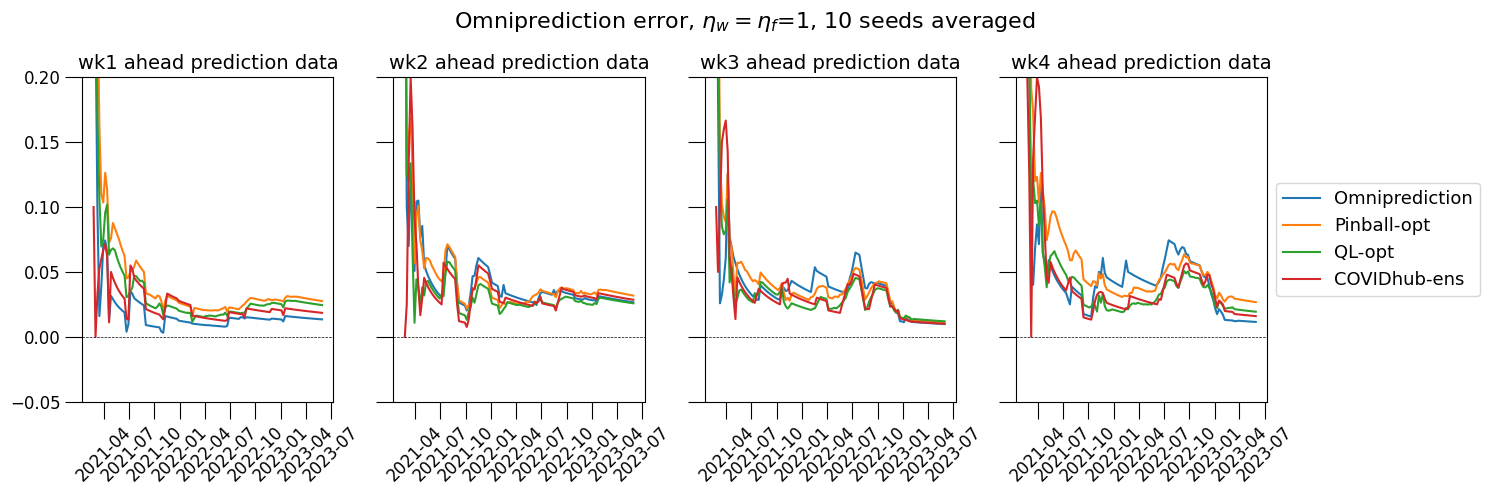

In [186]:
eta_multiplier = 1
eta_f_multiplier = 2
n_seed = 10
dates_list = pd.to_datetime(d['dates_list'])

fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharey='row')

for w in range(1,5):
    omni_trace_sum = np.zeros(len(dates_list))
    pb_trace_sum = np.zeros(len(dates_list))
    ql_trace_sum = np.zeros(len(dates_list))
    ens_trace_sum = np.zeros(len(dates_list))
    
    for seed in range(1, n_seed+1):
        exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
        omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'rb'))
        omni_trace_sum += (omni_result.results['omni_score_trace'] - omni_result.results['best_forecaster_score_trace'])
        pb_trace_sum += (omni_result.pinball_omni_score_trace - omni_result.results['best_forecaster_score_trace'])
        ql_trace_sum += (omni_result.ql_omni_score_trace - omni_result.results['best_forecaster_score_trace'])
        ens_trace_sum += (omni_result.ensemble_omni_score_trace - omni_result.results['best_forecaster_score_trace'])

    ax[w-1].plot(dates_list, omni_trace_sum/n_seed, label='Omniprediction')
    ax[w-1].plot(dates_list, pb_trace_sum/n_seed, label='Pinball-opt')
    ax[w-1].plot(dates_list, ql_trace_sum/n_seed, label='QL-opt')
    ax[w-1].plot(dates_list, ens_trace_sum/n_seed, label='COVIDhub-ens')
    
    # ax[w-1] = omni_result.simple_plot(ax=ax[w-1])
    ax[w-1].set_title(f'wk{w} ahead prediction data', fontsize=14)
    ax[w-1].set_ylim(-0.05, 0.2)
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
    ax[w-1].tick_params(axis='y', labelsize=12, size=12)
    ax[w-1].axhline(0, color='black', linewidth=0.5, linestyle='--')
    if w == 4:
        ax[w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=13)

fig.suptitle(r'Omniprediction error, $\eta_w=\eta_f$=1, 10 seeds averaged', fontsize=16)
fig.tight_layout()
plt.show()

In [93]:
results.keys()

dict_keys(['phat_history', 'minimax_value_history', 'forecasters_preds_history', 'omni_score_trace', 'forecasters_score_trace', 'best_forecaster_score_trace', 'thetas', 'pinball_selection_history', 'pinball_preds_history', 'ql_selection_history', 'ql_preds_history', 'Y', 'y_arr', 'dates_list', 'T', 'unit', 'm', 'F', 'eta_multiplier', 'eta_f_multiplier', 'seed', 'alpha_list', 'forecaster_names'])

In [203]:
ax

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

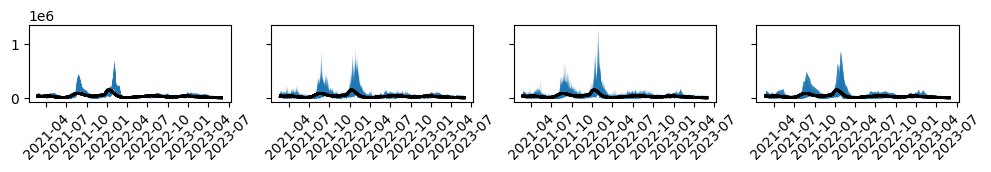

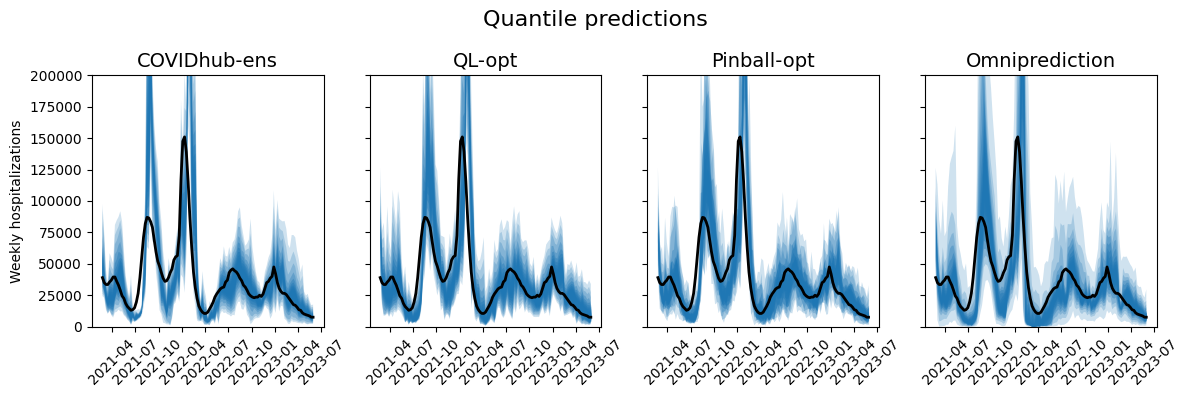

In [218]:
n_seed = 10

q_pred_omni = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_pb = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_ql = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_ens = np.zeros((len(d['dates_list']), len(d['alpha_list'])))

fig, ax = plt.subplots(1, 4, figsize=(12, 1), sharey=True)
for seed in range(1, n_seed+1):
    omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string(w=4, eta=1, eta_f=1, seed=seed)}.pkl", 'rb'))
    if seed == 10:
        fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
        omni_result.quantile_plot(ax=ax[3], q_preds=q_pred_omni/n_seed)
        omni_result.quantile_plot(ax=ax[2], q_preds=q_pred_pb/n_seed)
        omni_result.quantile_plot(ax=ax[1], q_preds=q_pred_ql/n_seed)
        omni_result.quantile_plot(ax=ax[0], q_preds=q_pred_ens/n_seed)
    else:
        ax[3], q_pred_omni = omni_result.quantile_plot(f_name='omni', ax=ax[3], q_preds_to_add=q_pred_omni)
        ax[2], q_pred_pb = omni_result.quantile_plot(f_name='pinball', ax=ax[2], q_preds_to_add=q_pred_pb)
        ax[1], q_pred_ql = omni_result.quantile_plot(f_name='ql', ax=ax[1], q_preds_to_add=q_pred_ql)
        ax[0], q_pred_ens = omni_result.quantile_plot(f_name='ens', ax=ax[0], q_preds_to_add=q_pred_ens)

ax[3].set_title('Omniprediction', fontsize=14)
ax[2].set_title('Pinball-opt', fontsize=14)
ax[1].set_title('QL-opt', fontsize=14)
ax[0].set_title('COVIDhub-ens', fontsize=14)

ax[0].set_ylabel('Weekly hospitalizations')


ax[0].set_ylim(0, 200000)

fig.suptitle('Quantile predictions', fontsize=16)
fig.tight_layout()
plt.show()

In [ ]:
print(results['forecaster_names'])

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']


0.12268907563025218
0.16470588235294123
0.14873949579831935
0.003238299527384586
0.004740817084196934
0.004504433610751454


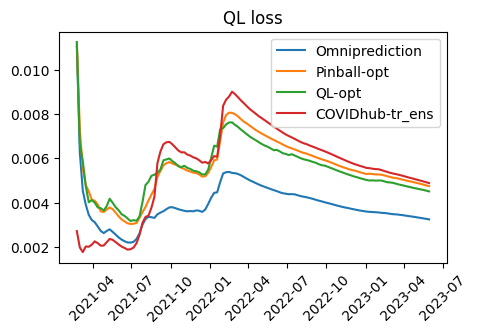

In [189]:
from metrics import ql_loss
w=4
eta_f_multiplier = 16

exp_name = exp_name_string(w, 1, eta_f_multiplier, seed=1)

omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'rb'))
results = omni_result.results

T = results['T']
Y = results['Y']
m = results['m']

print(results['omni_score_trace'][T-1])
print(omni_result.pinball_omni_score_trace[T-1])
print(omni_result.ql_omni_score_trace[T-1])

print(ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m)
print(ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m)
print(ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['phat_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Omniprediction')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Pinball-opt')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['ql_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='QL-opt')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['forecasters_preds_history'][:,:,-1], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='COVIDhub-tr_ens')
plt.xticks(rotation=45)
plt.legend()
plt.title('QL loss')
plt.show()

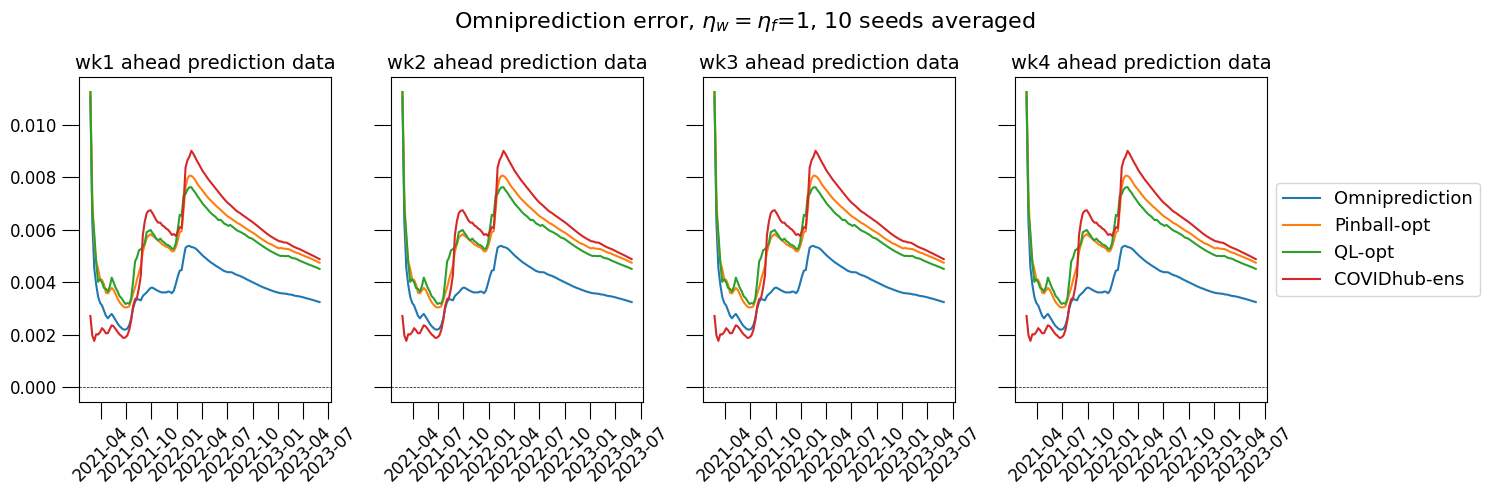

In [ ]:
eta_multiplier = 1
eta_f_multiplier = 2
n_seed = 10
dates_list = pd.to_datetime(d['dates_list'])

fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharey='row')

for w in range(1,5):
    omni_trace_sum = np.zeros(len(dates_list))
    pb_trace_sum = np.zeros(len(dates_list))
    ql_trace_sum = np.zeros(len(dates_list))
    ens_trace_sum = np.zeros(len(dates_list))
    
    for seed in range(1, n_seed+1):
        exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
        omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'rb'))
        omni_trace_sum += ql_loss(results['phat_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1)
        pb_trace_sum += ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1)
        ql_trace_sum += ql_loss(results['ql_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1)
        ens_trace_sum += ql_loss(results['forecasters_preds_history'][:,:,-1], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1)

    ax[w-1].plot(dates_list, omni_trace_sum/n_seed, label='Omniprediction')
    ax[w-1].plot(dates_list, pb_trace_sum/n_seed, label='Pinball-opt')
    ax[w-1].plot(dates_list, ql_trace_sum/n_seed, label='QL-opt')
    ax[w-1].plot(dates_list, ens_trace_sum/n_seed, label='COVIDhub-ens')
    
    # ax[w-1] = omni_result.simple_plot(ax=ax[w-1])
    ax[w-1].set_title(f'wk{w} ahead prediction data', fontsize=14)
    # ax[w-1].set_ylim(-0.05, 0.2)
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
    ax[w-1].tick_params(axis='y', labelsize=12, size=12)
    ax[w-1].axhline(0, color='black', linewidth=0.5, linestyle='--')
    if w == 4:
        ax[w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=13)

fig.suptitle(r'Quantile loss, $\eta_w=\eta_f$=1, 10 seeds averaged', fontsize=16)
fig.tight_layout()
plt.show()

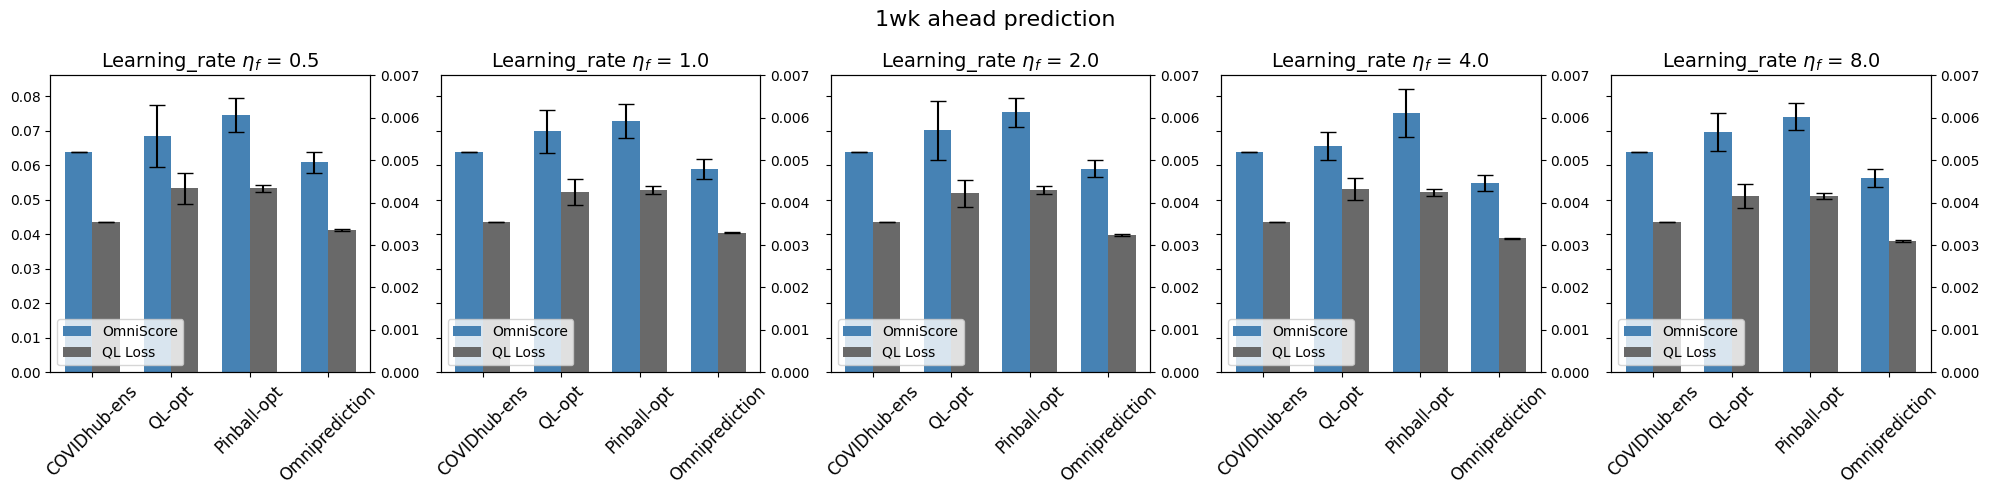

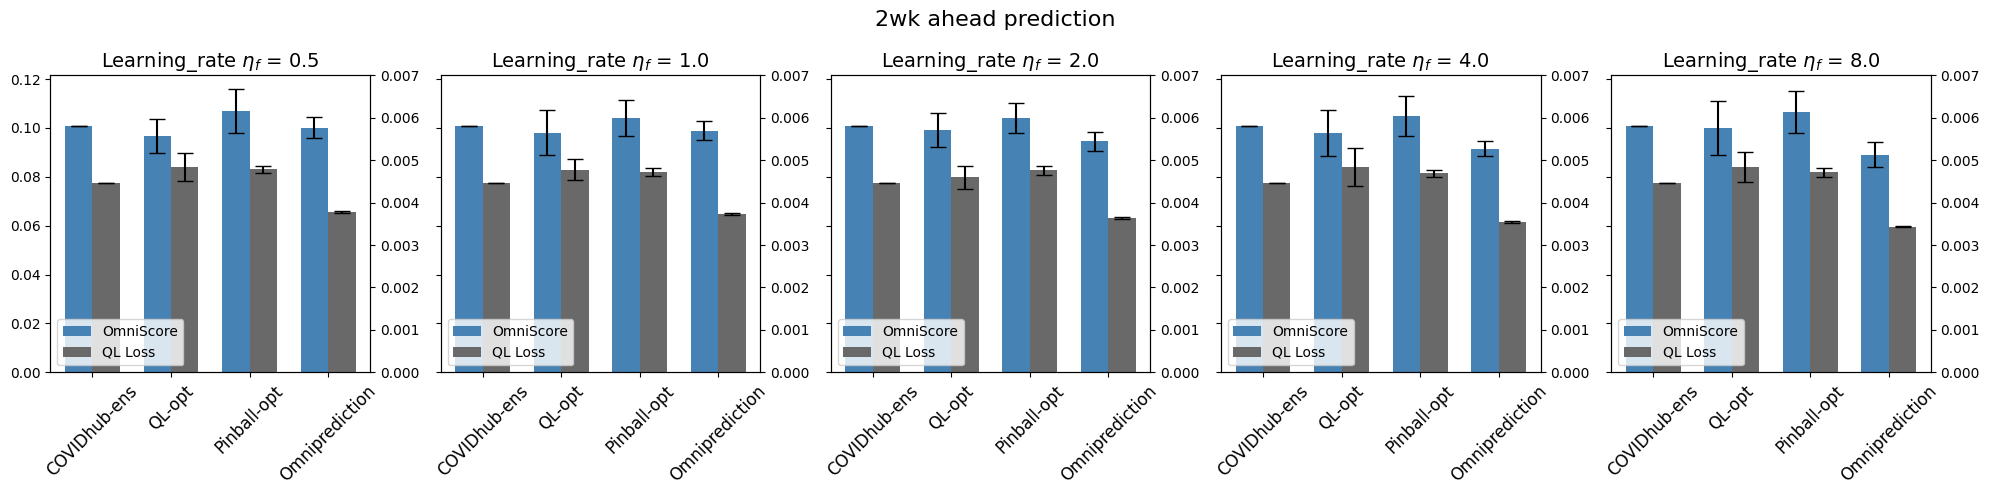

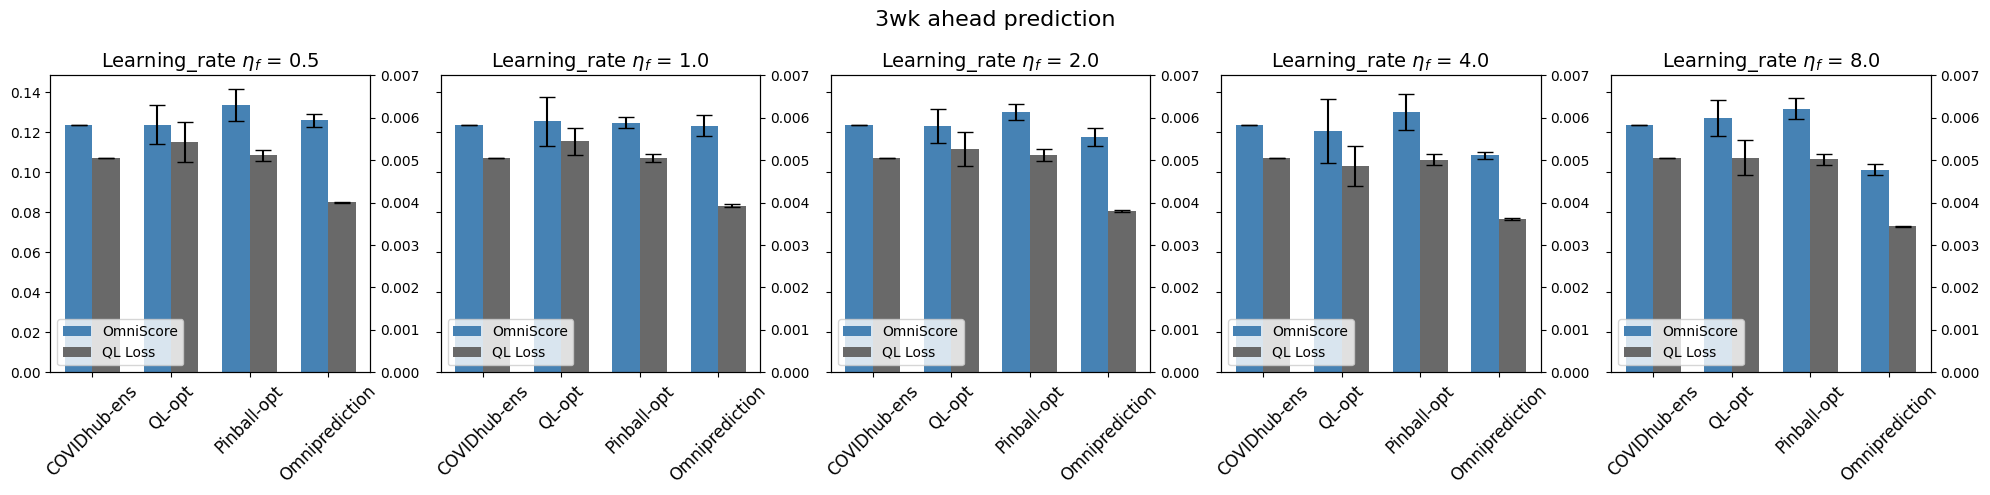

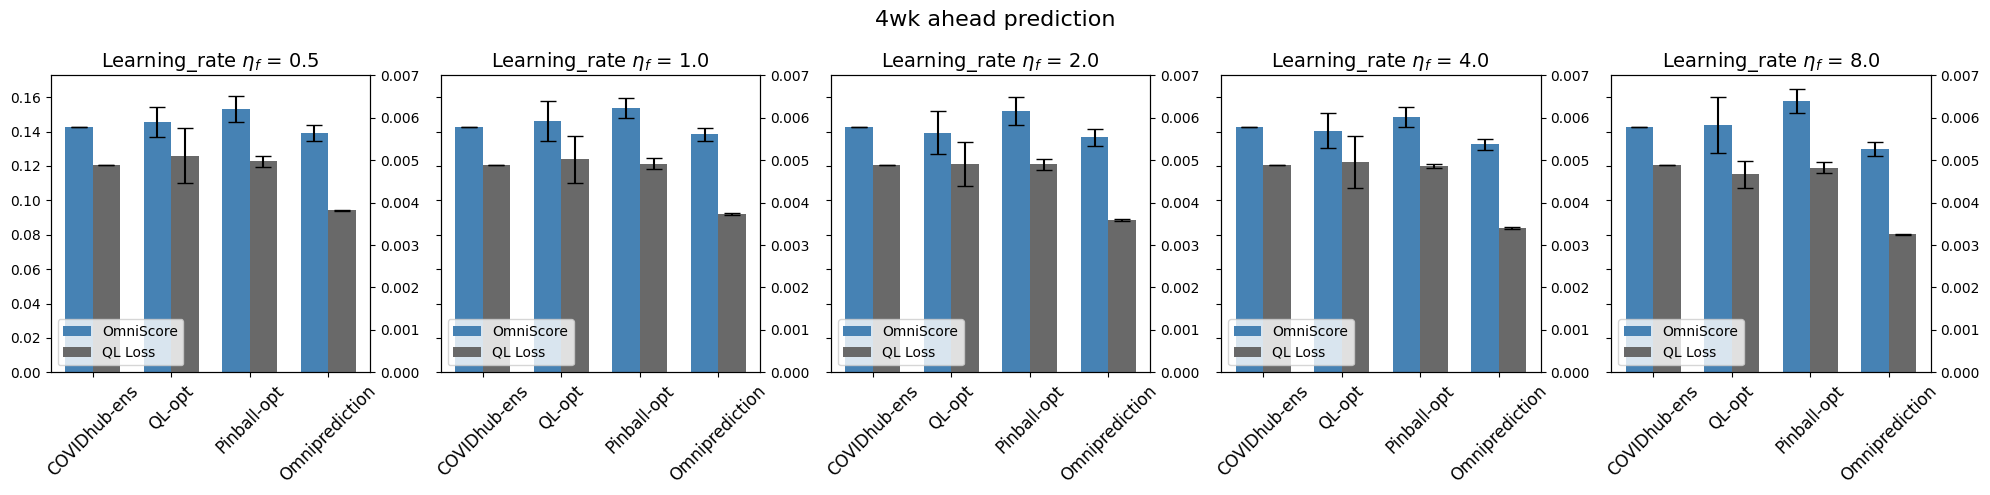

In [233]:
from metrics import elementary_scores_grid_T_N

alpha_list_here = np.array(d['alpha_list'])
n_seeds = 10
eta_multiplier = 1

for iw, w in enumerate(range(1,5)):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
    for iefm, eta_f_multiplier in enumerate([1, 2, 4, 8, 16]):
        ax = axes[iefm]
        
        ql_omni_score = np.zeros(n_seeds)
        pb_omni_score = np.zeros(n_seeds)
        ens_omni_score = np.zeros(n_seeds)
        omni_omni_score = np.zeros(n_seeds)
        
        ql_ql_loss = np.zeros(n_seeds)
        pb_ql_loss = np.zeros(n_seeds)
        ens_ql_loss = np.zeros(n_seeds)
        omni_ql_loss = np.zeros(n_seeds)

        for seed in range(1,n_seeds+1):
            omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)}.pkl", 'rb'))
            results = omni_result.results
            
            T = results['T']
            Y = results['Y']
            m = results['m']
            thetas = results['thetas']

            ens_preds = results['forecasters_preds_history'][:,:,-1]    # COVIDhub-trained_ensemble
            ensemble_scores = elementary_scores_grid_T_N(ens_preds, Y.values, thetas, alpha_list_here)
            ensemble_omni_score_trace = np.max(np.cumsum(ensemble_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

            ens_omni_score[seed-1] = ensemble_omni_score_trace[T-1]
            ql_omni_score[seed-1] = omni_result.ql_omni_score_trace[T-1]
            pb_omni_score[seed-1] = omni_result.pinball_omni_score_trace[T-1]
            omni_omni_score[seed-1] = results['omni_score_trace'][T-1]
            
            ens_ql_loss[seed-1] = ql_loss(ens_preds, Y, results['alpha_list']).mean()/m
            ql_ql_loss[seed-1] = ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m
            pb_ql_loss[seed-1] = ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m
            omni_ql_loss[seed-1] = ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m

        # Bar positions: 3 groups, 2 bars per group (omni_score, ql_loss)
        labels = [ 'COVIDhub-ens', 'QL-opt', 'Pinball-opt','Omniprediction']
        x = np.arange(4)
        width = 0.35  # width of each bar

        mean_omni = [ens_omni_score.mean(), ql_omni_score.mean(), pb_omni_score.mean(), omni_omni_score.mean()]
        std_omni = [ens_omni_score.std(), ql_omni_score.std(), pb_omni_score.std(), omni_omni_score.std()]
        mean_ql = [ens_ql_loss.mean(), ql_ql_loss.mean(), pb_ql_loss.mean(), omni_ql_loss.mean()]
        std_ql = [ens_ql_loss.std(), ql_ql_loss.std(), pb_ql_loss.std(), omni_ql_loss.std()]

        bars1 = ax.bar(x - width/2, mean_omni, width, yerr=std_omni, color='steelblue', capsize=6, label='OmniScore')
        ax_twin = ax.twinx()
        bars2 = ax_twin.bar(x + width/2, mean_ql, width, yerr=std_ql, color='dimgray', capsize=6, label='QL Loss')
        ax_twin.set_ylim(0, 0.007)

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, fontsize=12)
        ax.set_title(rf'Learning_rate $\eta_f$ = {eta_f_multiplier/2}', fontsize=14)
                
        lines = [bars1, bars2]
        labels = [l.get_label() for l in lines]
        ax_twin.legend(lines, labels, loc='lower left')

        fig.suptitle(f'{w}wk ahead prediction', fontsize=16)
        fig.tight_layout()

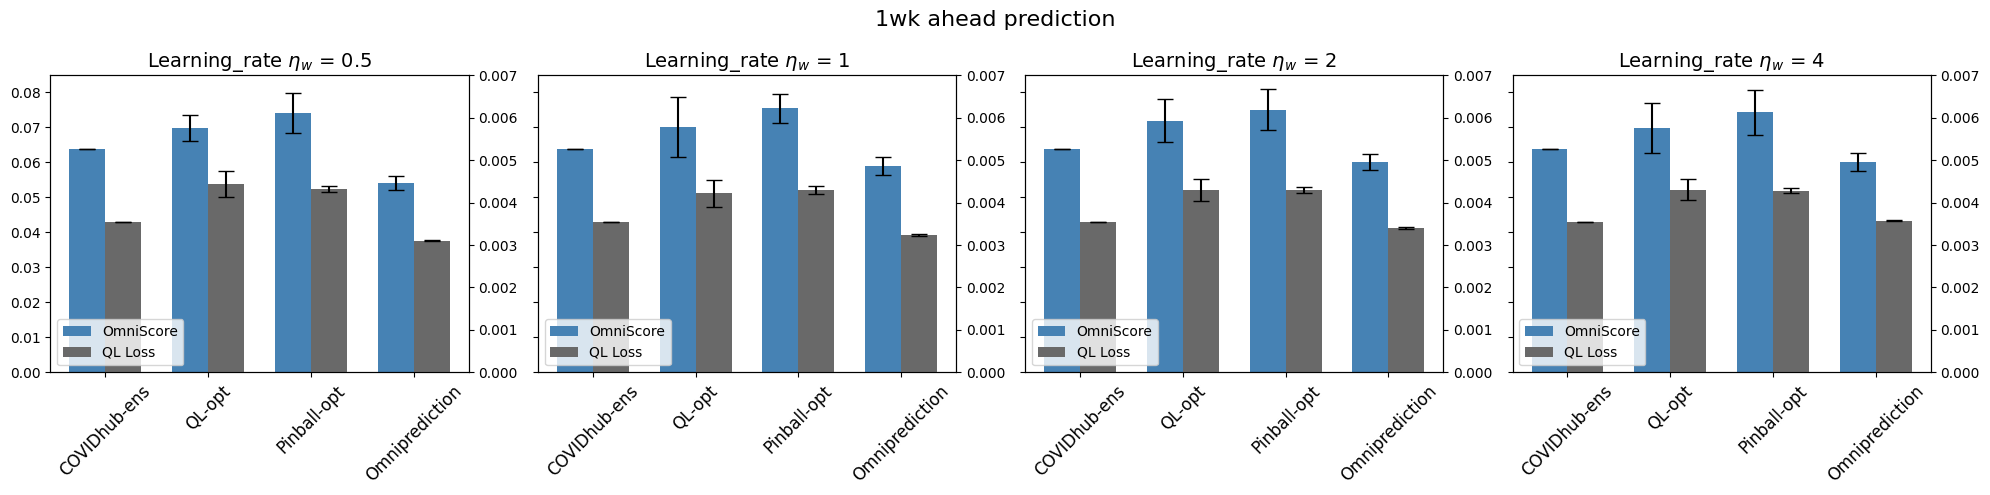

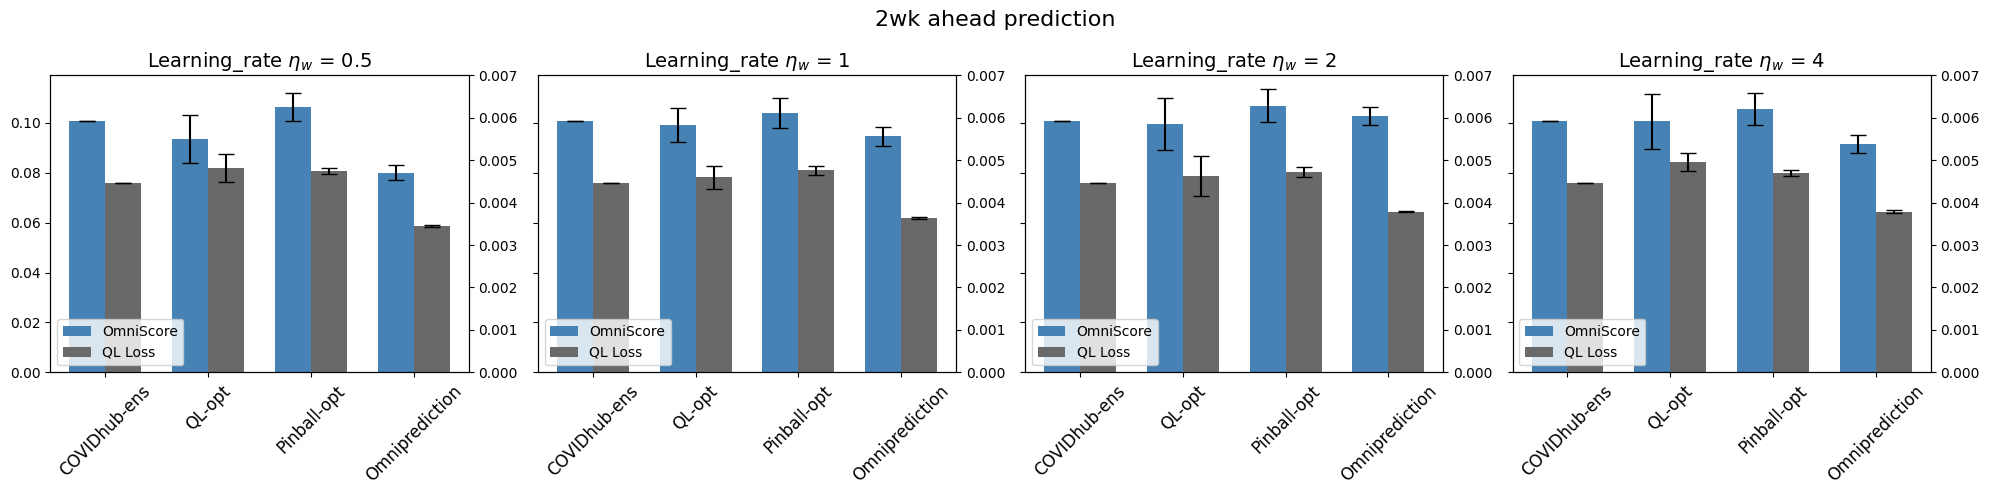

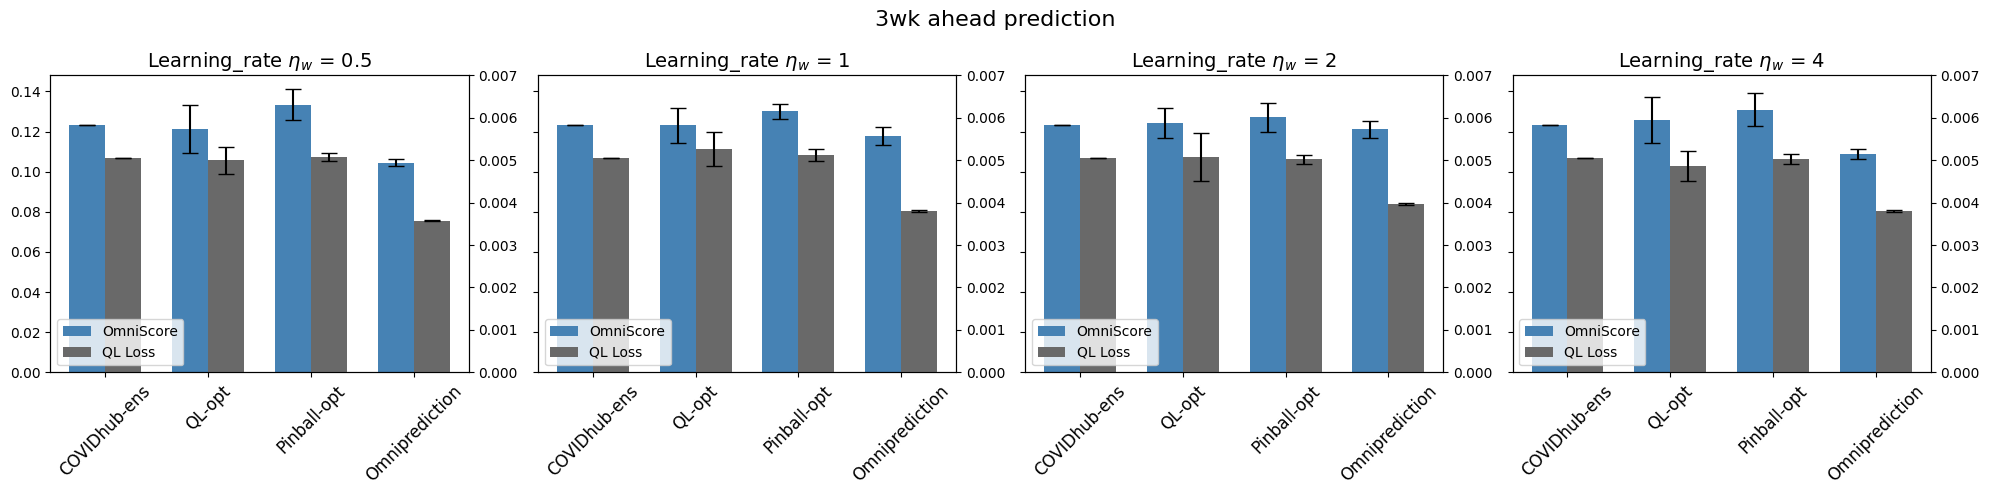

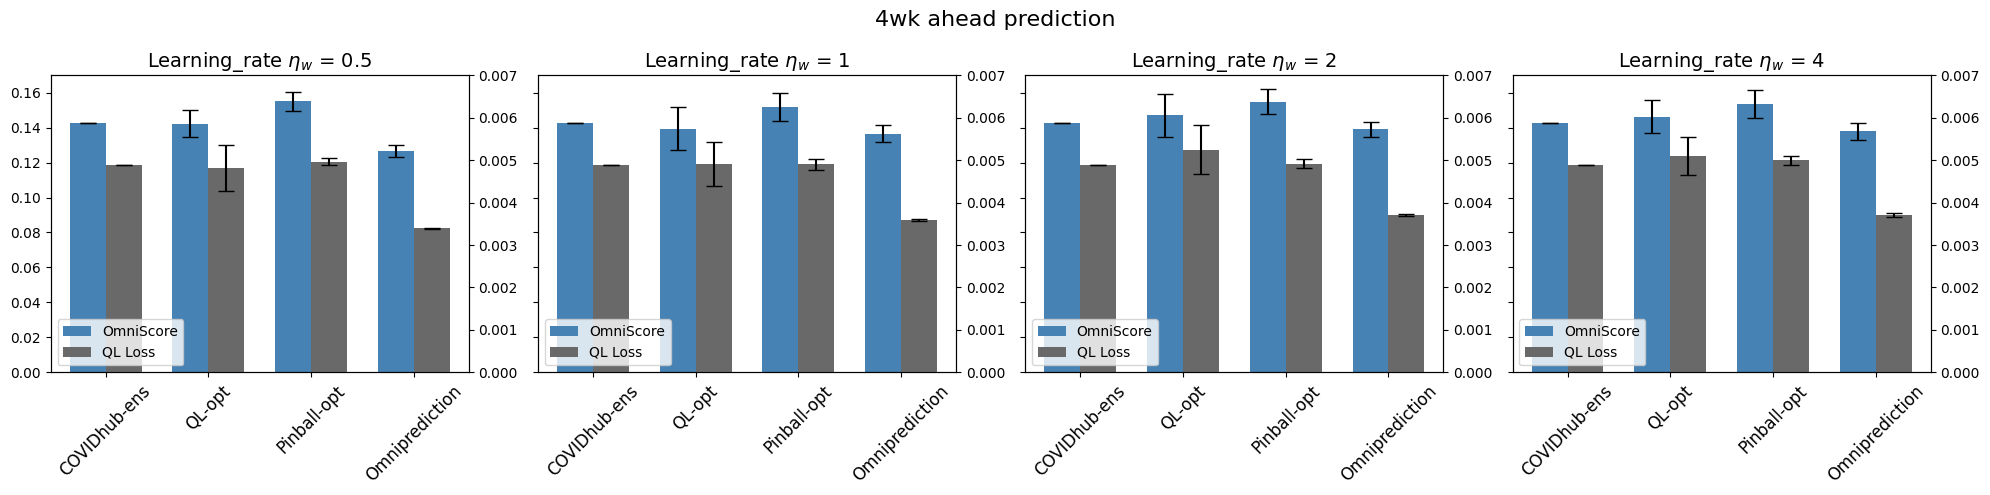

In [235]:
from metrics import elementary_scores_grid_T_N

alpha_list_here = np.array(d['alpha_list'])
n_seeds = 10
eta_f_multiplier = 4

for iw, w in enumerate(range(1,5)):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    for iefm, eta_multiplier in enumerate([0.5, 1, 2, 4]):
        ax = axes[iefm]
        
        ql_omni_score = np.zeros(n_seeds)
        pb_omni_score = np.zeros(n_seeds)
        ens_omni_score = np.zeros(n_seeds)
        omni_omni_score = np.zeros(n_seeds)
        
        ql_ql_loss = np.zeros(n_seeds)
        pb_ql_loss = np.zeros(n_seeds)
        ens_ql_loss = np.zeros(n_seeds)
        omni_ql_loss = np.zeros(n_seeds)

        for seed in range(1,n_seeds+1):
            omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)}.pkl", 'rb'))
            results = omni_result.results
            
            T = results['T']
            Y = results['Y']
            m = results['m']
            thetas = results['thetas']

            ens_preds = results['forecasters_preds_history'][:,:,-1]    # COVIDhub-trained_ensemble
            ensemble_scores = elementary_scores_grid_T_N(ens_preds, Y.values, thetas, alpha_list_here)
            ensemble_omni_score_trace = np.max(np.cumsum(ensemble_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

            ens_omni_score[seed-1] = ensemble_omni_score_trace[T-1]
            ql_omni_score[seed-1] = omni_result.ql_omni_score_trace[T-1]
            pb_omni_score[seed-1] = omni_result.pinball_omni_score_trace[T-1]
            omni_omni_score[seed-1] = results['omni_score_trace'][T-1]
            
            ens_ql_loss[seed-1] = ql_loss(ens_preds, Y, results['alpha_list']).mean()/m
            ql_ql_loss[seed-1] = ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m
            pb_ql_loss[seed-1] = ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m
            omni_ql_loss[seed-1] = ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m

        # Bar positions: 3 groups, 2 bars per group (omni_score, ql_loss)
        labels = [ 'COVIDhub-ens', 'QL-opt', 'Pinball-opt','Omniprediction']
        x = np.arange(4)
        width = 0.35  # width of each bar

        mean_omni = [ens_omni_score.mean(), ql_omni_score.mean(), pb_omni_score.mean(), omni_omni_score.mean()]
        std_omni = [ens_omni_score.std(), ql_omni_score.std(), pb_omni_score.std(), omni_omni_score.std()]
        mean_ql = [ens_ql_loss.mean(), ql_ql_loss.mean(), pb_ql_loss.mean(), omni_ql_loss.mean()]
        std_ql = [ens_ql_loss.std(), ql_ql_loss.std(), pb_ql_loss.std(), omni_ql_loss.std()]

        bars1 = ax.bar(x - width/2, mean_omni, width, yerr=std_omni, color='steelblue', capsize=6, label='OmniScore')
        ax_twin = ax.twinx()
        ax_twin.set_ylim(0, 0.007)
        bars2 = ax_twin.bar(x + width/2, mean_ql, width, yerr=std_ql, color='dimgray', capsize=6, label='QL Loss')
        

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, fontsize=12)
        ax.set_title(rf'Learning_rate $\eta_w$ = {eta_multiplier}', fontsize=14)
        
        lines = [bars1, bars2]
        labels = [l.get_label() for l in lines]
        ax_twin.legend(lines, labels, loc='lower left')

        fig.suptitle(f'{w}wk ahead prediction', fontsize=16)
        fig.tight_layout()

### Murphy diagram

In [18]:
pb_murphy.shape

(119, 23, 2604)

100%|██████████| 10/10 [00:04<00:00,  2.35it/s]


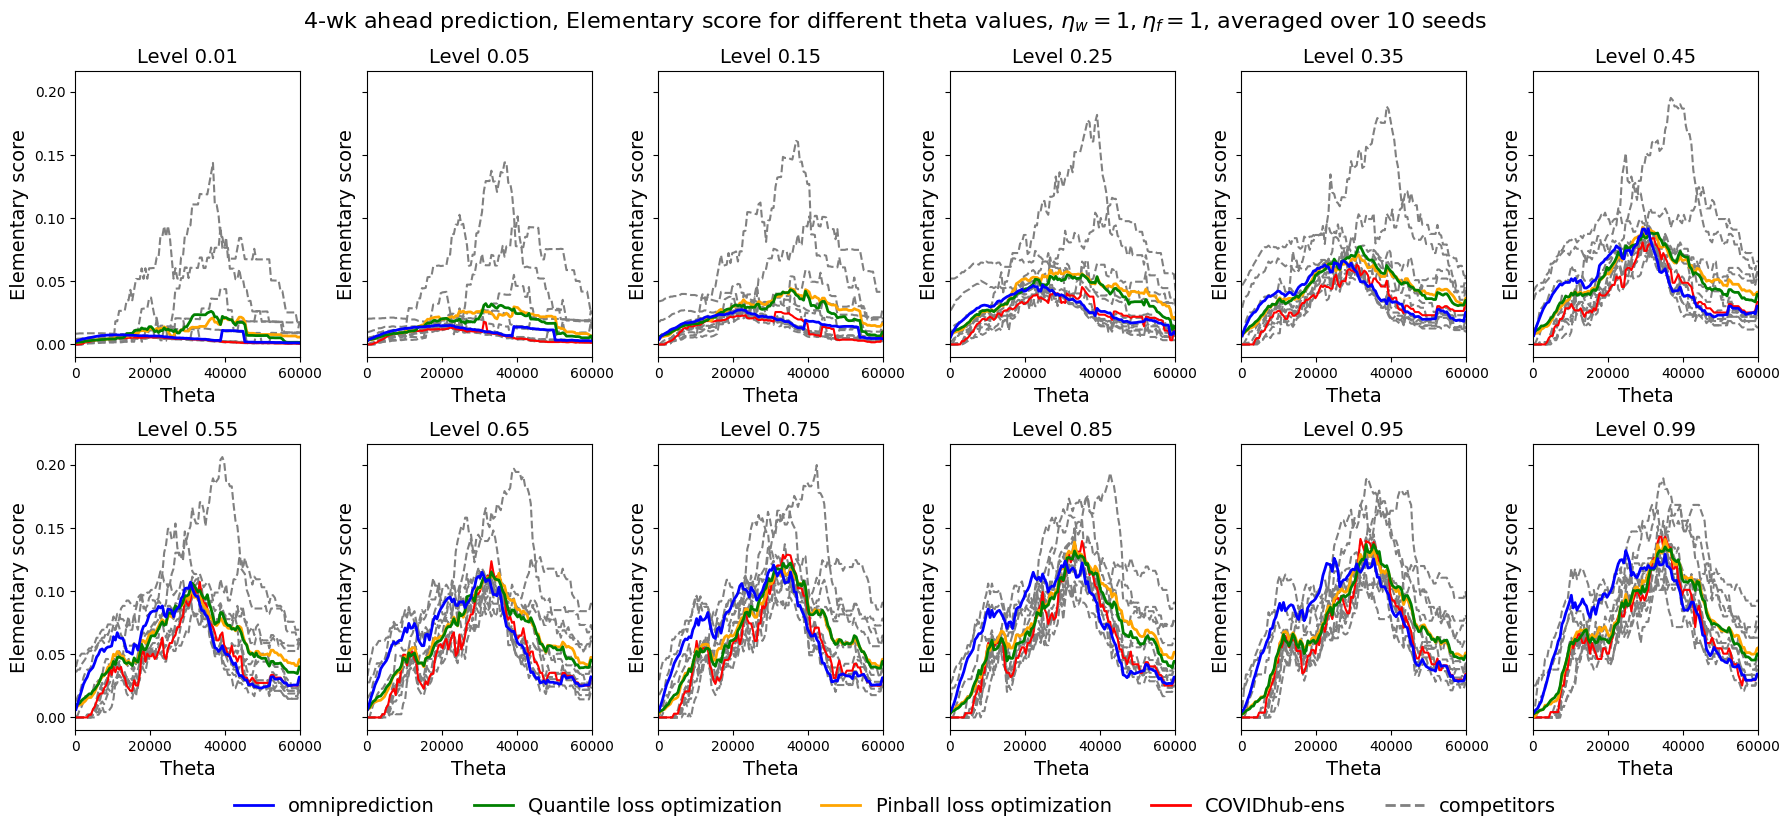

In [24]:
import importlib
import metrics
importlib.reload(metrics)
from metrics import elementary_scores_grid_T_N, elementary_scores_grid_T_N_F
from tqdm import tqdm

w=4
F=12
eta_multiplier = 1
eta_f_multiplier = 1    

omni_murphy = np.zeros((len(alpha_list), len(thetas)))
ql_murphy = np.zeros((len(alpha_list), len(thetas)))
pb_murphy = np.zeros((len(alpha_list), len(thetas)))
f_murphy = np.zeros((len(alpha_list), len(thetas), F))

for seed in tqdm(range(1, 11)):
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)}.pkl", 'rb'))
    omni_result = OmniResult(results)

    thetas = results['thetas']
    unit = results['unit'] 
    F = results['F']
    forecaster_names = results['forecaster_names']

    omni_murphy += elementary_scores_grid_T_N(p_grid_T_N=results['phat_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
    ql_murphy += elementary_scores_grid_T_N(p_grid_T_N=results['ql_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
    pb_murphy += elementary_scores_grid_T_N(p_grid_T_N=results['pinball_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
    f_murphy += elementary_scores_grid_T_N_F(p_grid_T_N_F=results['forecasters_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)

omni_murphy /= 10
ql_murphy /= 10
pb_murphy /= 10
f_murphy /= 10

fig, ax = plt.subplots(2, 6, figsize=(18, 8), sharey=True)
ax = ax.flatten()

for ia, alpha in enumerate(alpha_list[::2]):
    df = omni_result.single_q_pred_df(ia)
    
    for f in range(F):
        if f < F-1:
            ax[ia].plot(thetas*unit, f_murphy[ia,:,f], linestyle='--', color='gray')
        else:
            ax[ia].plot(thetas*unit, f_murphy[ia,:,f], linestyle='-', color='red')
    ax[ia].plot(thetas*unit, pb_murphy[ia,:], color='orange', linewidth=2, label='Pinball loss optimization')
    ax[ia].plot(thetas*unit, ql_murphy[ia,:], color='green', linewidth=2, label='Quantile loss optimization')
    ax[ia].plot(thetas*unit, omni_murphy[ia,:], color='blue', linewidth=2, label='omniprediction')    

    # if ia == 4:
    # Add a custom legend to the bottom of the entire figure
    ax[ia].set_xlabel('Theta', fontsize=14)
    ax[ia].set_ylabel('Elementary score', fontsize=14)
    ax[ia].set_title(f'Level {alpha}', fontsize=14)
    ax[ia].set_xlim(0, 60000)

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='blue', linewidth=2, label='omniprediction'),
    Line2D([0], [0], color='green', linewidth=2, label='Quantile loss optimization'),
    Line2D([0], [0], color='orange', linewidth=2, label='Pinball loss optimization'),
    Line2D([0], [0], color='red', linewidth=2, label='COVIDhub-ens'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='competitors'),
]
fig.legend(
    handles=custom_lines, 
    loc='lower center', 
    ncol=5, 
    bbox_to_anchor=(0.5, -0.05), 
    fontsize=14, 
    frameon=False
)

fig.suptitle(rf'{w}-wk ahead prediction, Elementary score for different theta values, $\eta_w=1, \eta_f=1$, averaged over 10 seeds', fontsize=16)
fig.tight_layout()
plt.show()



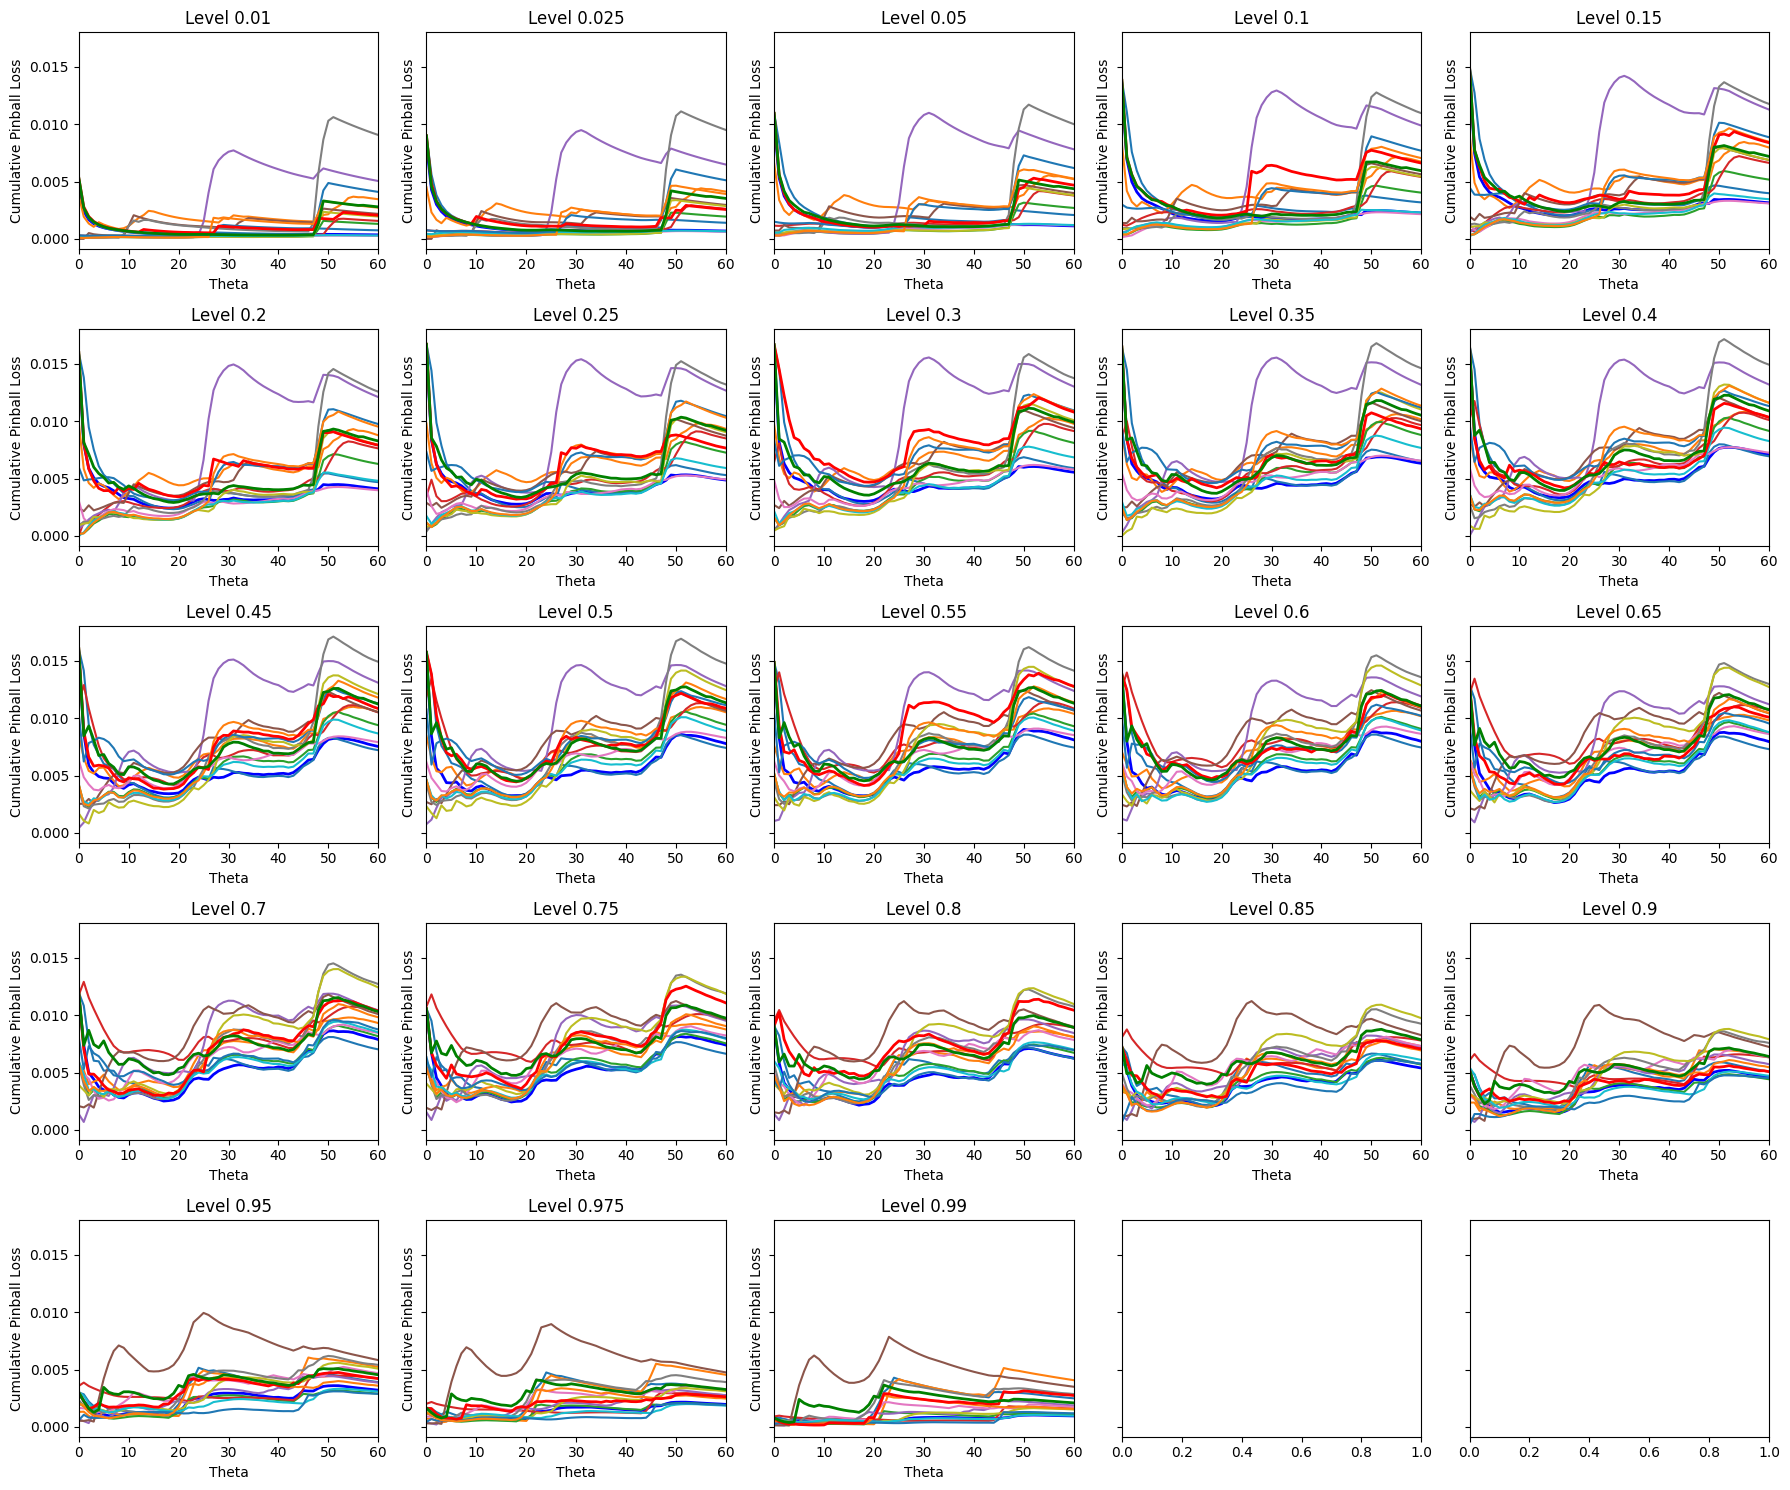

In [85]:
from metrics import pinball_loss

T = results['T']
F = results['F']
m = results['m']
forecaster_names = results['forecaster_names']

fig, ax = plt.subplots(5, 5, figsize=(18, 15), sharey='all')
ax = ax.flatten()
for ia, alpha in enumerate(alpha_list_here):    
    df = omni_result.single_q_pred_df(ia)
    ax[ia].plot(pinball_loss(df["phat"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, color='blue', linewidth=2,label='Omniprediction')
    for f in range(F):
        ax[ia].plot(pinball_loss(df[f"pred_{f+1}"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, label=forecaster_names[f])
    ax[ia].plot(pinball_loss(df["pinball_pred"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, color='red', linewidth=2, label='Pinball loss optimization')
    ax[ia].plot(pinball_loss(df["ql_pred"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, color='green', linewidth=2, label='Quantile loss optimization')
    # if ia == 4:
    #     ax[ia].legend()
    ax[ia].set_xlim(0, 60)
    ax[ia].set_xlabel('Theta')
    ax[ia].set_ylabel('Cumulative Pinball Loss')
    ax[ia].set_title(f'Level {alpha}')

fig.tight_layout()
plt.show()